MAGGIE HA

In this project, we develop a tutorial to demonstrate how a neural network performs a computer vision classification task.
The dataset we use in this tutorial is pneumonia_mnist available on Tensorflow.

The dataset  is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. Each image is 28 x 28 pixels.



We use tf.keras to build and train models in TensorFlow.

In [ ]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


**1. Import the pneumonia_mnist dataset.**

In [ ]:
# Create the function to load the dataset
def load_pneumonia_mnist():
    import numpy as np
    import medmnist
    from medmnist import PneumoniaMNIST

    train_dataset = PneumoniaMNIST(split='train', download=True)
    test_dataset  = PneumoniaMNIST(split='test', download=True)

    train_images = np.stack([np.array(img[0]) for img in train_dataset])
    train_labels = np.array([int(img[1]) for img in train_dataset])
    test_images  = np.stack([np.array(img[0]) for img in test_dataset])
    test_labels  = np.array([int(img[1]) for img in test_dataset])

    return (train_images, train_labels), (test_images, test_labels)

(train_images, train_labels), (test_images, test_labels) = load_pneumonia_mnist()


/tmp/ipython-input-941574913.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  train_labels = np.array([int(img[1]) for img in train_dataset])
/tmp/ipython-input-941574913.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  test_labels  = np.array([int(img[1]) for img in test_dataset])


The images are 28x28 NumPy arrays, with pixel values ranging from 0 to 255. The labels are an array of integers including 0 and 1.
Each image is mapped to a single label. Since the class names are not included with the dataset, store them here to use later when plotting the images.

In [ ]:
label_names = ['Normal', 'Pneumonia']

**2. Explore the data**

We explore the format of the dataset before training the model. The following shows there are 4,708 images in the training set, with each image represented as 28 x 28 pixels.

In [ ]:
train_images.shape

(4708, 28, 28)

There are also 4,708 labels in the training set.

In [ ]:
len(train_labels)

4708

Each label is an integer 0 or 1.

In [ ]:
train_labels

array([1, 1, 1, ..., 1, 0, 1])

There are 624 images in the test set, and each image is represented as 28 x 28 pixels.

In [ ]:
test_images.shape

(624, 28, 28)

And the test set contains 624 images labels.

In [ ]:
len(test_labels)

624

**3. Preprocess the data**

We preprocess the data before training the network. First, we want to inspect the fisrt image in the training set.

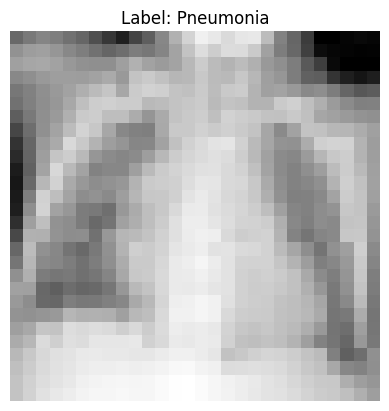

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0].squeeze(), cmap='gray')
plt.title(f"Label: {label_names[train_labels[0]]}")
plt.axis('off')
plt.show()


We display the first 25 images from the training set and display the class name below each image.

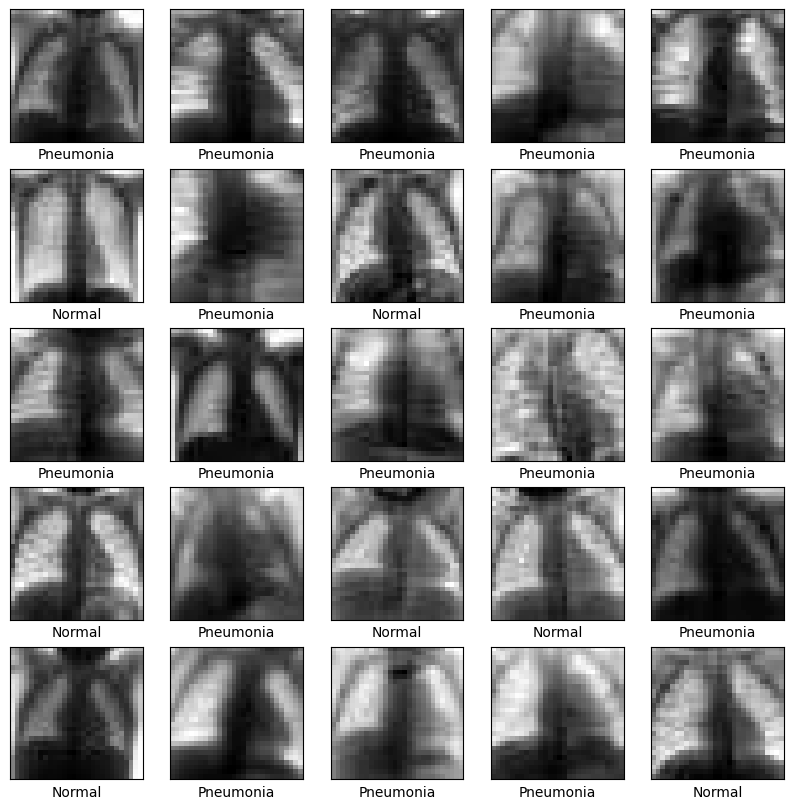

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(label_names[train_labels[i]])
plt.show()

**4. Build the model**

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the training set and the testing set be preprocessed in the same way.

In [ ]:
train_images = train_images / 255.0

test_images = test_images / 255.0

We configure the layers of the model and then compile the model.

First, we set up the layers.

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(), # Batch Normalization Layer
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The first layer in this network, tf.keras.layers.Flatten, transforms the format of the images from a two-dimensional array (of 28 by 28 pixels) to a one-dimensional array (of 28 * 28 = 784 pixels).This layer has no parameters to learn; it only reformats the data.

After the first layer, the network consists of a sequence of two tf.keras.layers.Dense layers. These are densely connected, or fully connected, neural layers. The first Dense layer has 128 nodes (or neurons). The second (and last) layer returns a logits array with length of 2. Each node contains a score that indicates the current image belongs to one of the 2 classes.

Batch Normalization reduces overfitting through stabilizing layer inputs by normalizing them across each training mini-batch. This dependency on the specific samples in the mini-batch introduces a random noise component to the activation values. This noise injection prevents the network from relying too heavily on specific training examples or features, making the model more robust and less likely to memorize the training data, thereby improving generalization.

Next, we compile the model.

There are three steps for model compiler.


*   Optimizer: This is how the model is updated based on the data it sees and its loss function.
*   Loss function This measures how accurate the model is during training. We want to minimize this function to "steer" the model in the right direction
*   Metrics: Used to monitor the training and testing steps. In this tutorial, we uses accuracy, the fraction of the images that are correctly classified.

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy', 'AUC'])

Adam (Adaptive Moment Estimation) is a robust and efficient optimizer that performs well in almost all deep learning scenarios, including both binary and multiclass classification. It uses adaptive learning rates for each weight, combining the benefits of Momentum and Adagrad.

The typical loss function for binary classification is Binary Cross Entropy, which is often used in binary classification. It ensures when the model is confidently wrong. By using Mean Squared Error, when the model is confidently wrong (i.e., predicting a probability close to the wrong class), the resulting loss gradient is very small, leading to a vanishing gradient problem. This weak gradient means the model struggles to quickly correct highly confident errors, making training slow and ineffective compared to Binary Cross Entropy.

Metrics: Accuracy is the ratio of correctly predicted instances to the total instances. It is a necessary metric for any classification task. Metric AUC is often used in medicine because it provides a single, reliable number ranging from 0.5 (random guess) to 1.0 (perfect discrimination) that tells a medical professional the probability that the model will correctly rank a randomly chosen sick patient higher than a randomly chosen healthy patient

**5. Train the model**

There are four steps in training the model.
*   Step 1: Feed the training data to the model.
*   Step 2: the model learns to associate images and labels.
*   Step 3: ask the model to make predictions from a instance in the testing data.
*   Step 4: verify that the predictions match the true label.

Feed the data in the training data set.

In [ ]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.9592 - accuracy: 0.8928 - loss: 0.2494
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9887 - accuracy: 0.9584 - loss: 0.1147
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9936 - accuracy: 0.9686 - loss: 0.0914
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9944 - accuracy: 0.9729 - loss: 0.0803
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9953 - accuracy: 0.9729 - loss: 0.0748
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9955 - accuracy: 0.9766 - loss: 0.0695
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9965 - accuracy: 0.9760 - loss: 0.0685
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9979 - accuracy: 0.9811 - loss: 0.0543
Epoch 9/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9983 - accuracy: 0.9820 - loss: 0.0487
Epoch 10/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9979 - accuracy: 0.9841 - loss: 0.0468


As the model trains, the loss and accuracy metrics are displayed. This model reaches an accuracy of about 0.98 (or 98%) on the training data.

Evaluate the accuracy.

Next, we compare how the model performs on the test dataset.

In [ ]:
test_loss, test_acc, test_auc = model.evaluate(test_images, test_labels, verbose=2)

print('\nTest loss:', test_loss)
print('Test accuracy:', test_acc)
print('Test AUC:', test_auc)


20/20 - 1s - 27ms/step - AUC: 0.8328 - accuracy: 0.7212 - loss: 1.7550

Test loss: 1.7550088167190552
Test accuracy: 0.7211538553237915
Test AUC: 0.8328292369842529


The accuracy on the test dataset is less than the accuracy on the training dataset. This gap between training accuracy and test accuracy represents overfitting. Overfitting happens when a machine learning model performs worse on new, previously unseen inputs than it does on the training data. An overfitted model "memorizes" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data.

Make the prediction

With the model trained, you can use it to make predictions about some images.
The last layer is sigmoid, so we want to convert the probability to the class label, which should be easier to interpret.

In [ ]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Activation('sigmoid')])

In [ ]:
# Predict on the test set
y_pred_probs = probability_model.predict(test_images)

# Convert the probebility to class label
y_pred_classes = (y_pred_probs > 0.5).astype("int32")

# Convert the number label to the Pneumonia or Normal label
y_pred_labels = [label_names[i[0]] for i in y_pred_classes]


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
# Make the prediction for the first image in the testing dataset, the class value is the first entry of the resulting array of length 2
y_pred_probs[0][0]

np.float32(0.73105854)

In [ ]:
y_pred_classes[0][0]

np.int32(1)

In [ ]:
y_pred_labels[0]

'Pneumonia'

We make another prediction along with the image in the testing dataset.

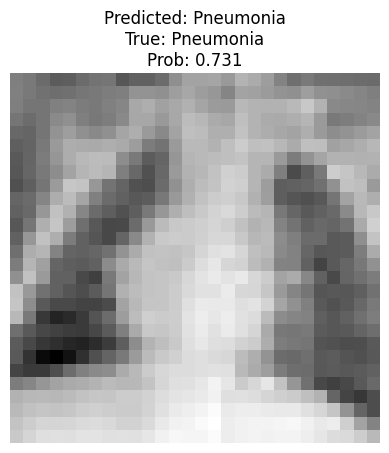

In [ ]:
import matplotlib.pyplot as plt

label_names = ['Normal', 'Pneumonia']
i = 23 # pick a test image

plt.imshow(test_images[i], cmap='gray')
plt.title(f"Predicted: {label_names[y_pred_classes[i][0]]}\nTrue: {label_names[test_labels[i]]}\nProb: {y_pred_probs[i][0]:.3f}")
plt.axis('off')
plt.show()


Verify predictions

We define functions to graph the full set of the 2 class predictions.

In [ ]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(label_names[predicted_label],
                                100*np.max(predictions_array),
                                label_names[true_label]),
                                color=color)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_value_array_fixed(i, predictions_array, true_label):

    p = np.squeeze(predictions_array)

    if p.ndim > 0:
        p = p[i]

    true_label_val = np.squeeze(true_label[i])

    two_class_preds = np.array([p, 1 - p])

    plt.grid(False)
    plt.xticks(range(2))
    plt.yticks([])

    thisplot = plt.bar(range(2), two_class_preds, color="#777777")
    plt.ylim([0, 1])

    predicted_label = 1 if p >= 0.5 else 0

    thisplot[predicted_label].set_color('red')
    thisplot[true_label_val].set_color('blue')

Make the prediction of the ith image in the testing dataset and display the bar graph for the prediction.

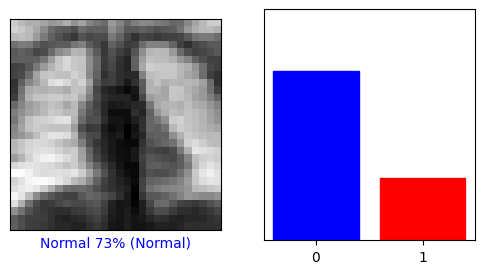

In [ ]:
i = 44
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, y_pred_probs[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array_fixed(i, y_pred_probs[i],  test_labels)
plt.show()

Let's plot several images with their predictions. Note that the model can be wrong even when very confident.

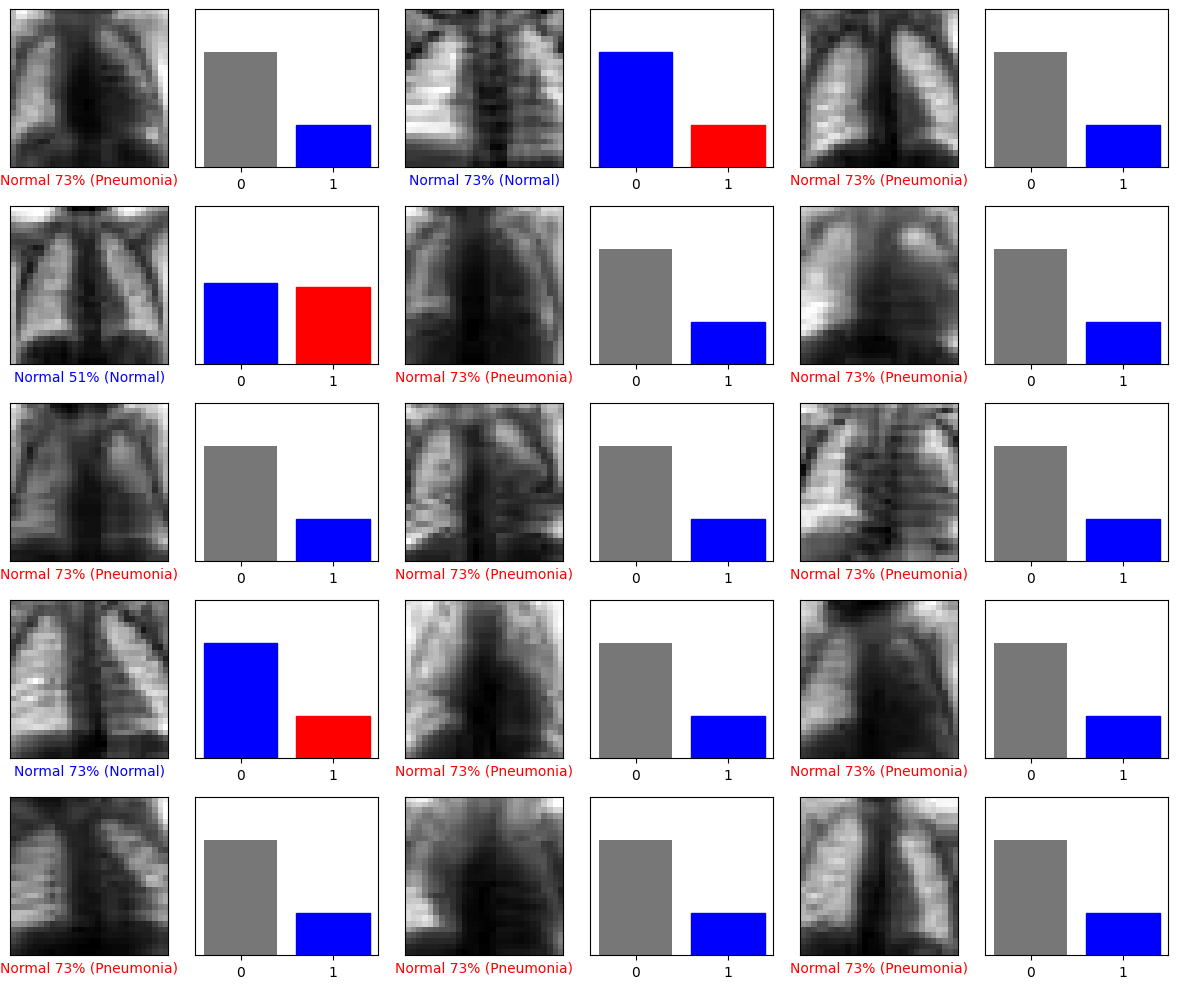

In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, y_pred_probs[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array_fixed(i, y_pred_probs[i], test_labels)
plt.tight_layout()
plt.show()

**5. Evaluate performance of the model**

Using confucion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np

# Ensure test_labels are 1D array
y_true = np.squeeze(test_labels)

# Extract and ensure predictions are 1D array
y_pred_probs_scalar = np.squeeze(y_pred_probs)

# Convert probabilities to hard class predictions (0 or 1)
y_pred_classes = (y_pred_probs_scalar >= 0.5).astype(int)

# Compute the Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("--- Confusion Matrix ---")
# Scikit-learn orders are: [[TN, FP], [FN, TP]]
print(cm)
print("\n")

# Get all core metrics (Precision, Recall, F1-Score, Support)
print("--- Classification Report (Metrics) ---")
print(classification_report(y_true, y_pred_classes, target_names=['Normal (0)', 'Pneumonia (1)']))

--- Confusion Matrix ---
[[  0 234]
 [  0 390]]


--- Classification Report (Metrics) ---
               precision    recall  f1-score   support

   Normal (0)       0.00      0.00      0.00       234
Pneumonia (1)       0.62      1.00      0.77       390

     accuracy                           0.62       624
    macro avg       0.31      0.50      0.38       624
 weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


True Negatives (TN) = 0: The model correctly identified zero normal cases as normal.

False Positives (FP) = 234: The model incorrectly flagged 234 normal cases as having pneumonia (False Alarms).

False Negatives (FN) = 0: The model incorrectly identified zero pneumonia cases as normal.

True Positives (TP) = 390: The model correctly identified 390 pneumonia cases as having pneumonia.

Sensitivity = 1, the model caught all the true pneumonia cases.

Recall = 0, the model missed all the true normal cases.

Precision = 0.62, Of all its 'Pneumonia' cases, only 62% were correct.

Accurary = 0.62, it predict correctly 62.5% of the time, just by always guessing "Pneumonia."

The recall is 0, and the matrix indicates that the model predicts the positive class (Pneumonia) for every single test case, which is a serious problem.

Evaluating AUC

In [ ]:
# Compute ROC AUC Score
auc_score = roc_auc_score(y_true, y_pred_probs_scalar)
print(f"--- ROC AUC Score (Discrimination Ability) ---")
print(f"AUC: {auc_score:.4f}")

--- ROC AUC Score (Discrimination Ability) ---
AUC: 0.9461


**6. Potential limitations**

The problem is that the binary classification model is suffering from extreme bias, classifying every single test case as the positive class (Pneumonia). While this results in perfect sensitivy for the Pneumonia class (no False Negatives), it yields zero specificity (recall 0f 0) as every single Normal patient is incorrectly flagged as having the disease (234 False Positives). This model is effectively useless for diagnosis because it cannot distinguish between healthy and sick individuals.

The AUC measure how well the model can distinguish between the two classes. An AUC of 0.95 means there is a 95% probability that the model will rank a randomly chosen positive instance (a patient with pneumonia) higher (assign a higher probability score to it) than a randomly chosen negative instance (a patient who is normal).

Tha AUC of 0.95 confirms that the underlying problem is not the model's ability to learn, but rather an issue with the final decision boundary or loss function settings that caused the extreme bias (the 0 TN and 0 FN in Confusion Matrix).

As mentioned above, there are potential overfitting because the accuracy on the test dataset is less than the accuracy on the training dataset.

**7. References**


TensorFlow. “Basic Classification: Classify Images of Clothing.” TensorFlow, 16 Aug. 2024, https://www.tensorflow.org/tutorials/keras/classification#evaluate_accuracy.

Yang, Jiancheng, et al. “MedMNIST v2: A Large-Scale Lightweight Benchmark for 2D and 3D Biomedical Image Classification.” Scientific Data, vol. 10, no. 1, 2023, p. 41. Nature Publishing Group UK, London.